# Employee Workforce Segmentation Using K-Means and Hierarchical Clustering

# # INTRODUCTION

Employee segmentation is an important application of unsupervised machine learning that helps organizations understand workforce characteristics and identify distinct employee groups. By clustering employees based on factors such as age, income, experience, job satisfaction, and work-life balance, organizations can gain valuable insights into workforce composition and employee behavior.

In this project, K-Means Clustering and Hierarchical Clustering is used to segment employees into meaningful groups. Principal Component Analysis (PCA) is applied to visualize the clusters and better understand the differences between employee segments and comparing which clustering is best using silhouette score. The insights obtained from this analysis can support workforce planning, employee engagement strategies, and organizational decision-making.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [5]:
df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours', 'Attrition'], axis="columns", inplace=True)

# # EDA

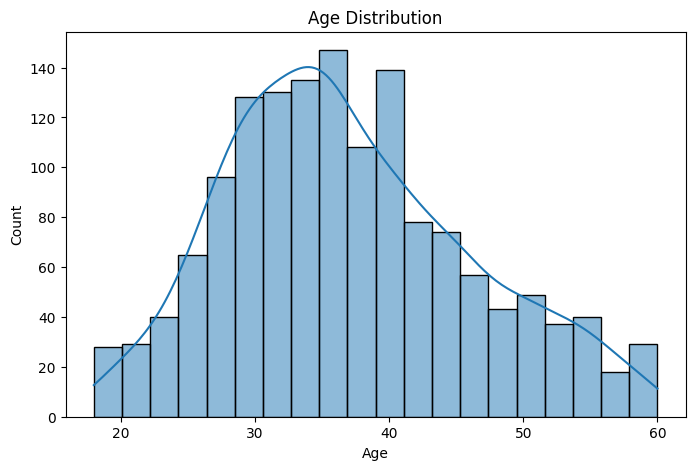

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.show()

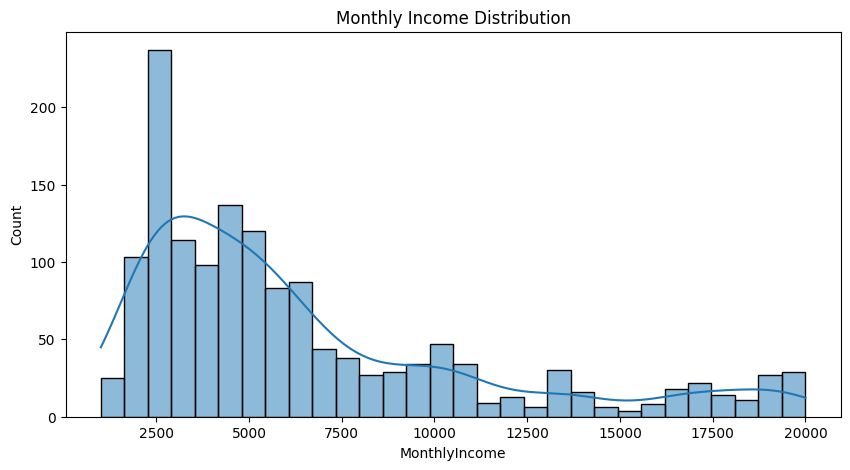

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(df['MonthlyIncome'], bins=30, kde=True)

plt.title("Monthly Income Distribution")
plt.show()

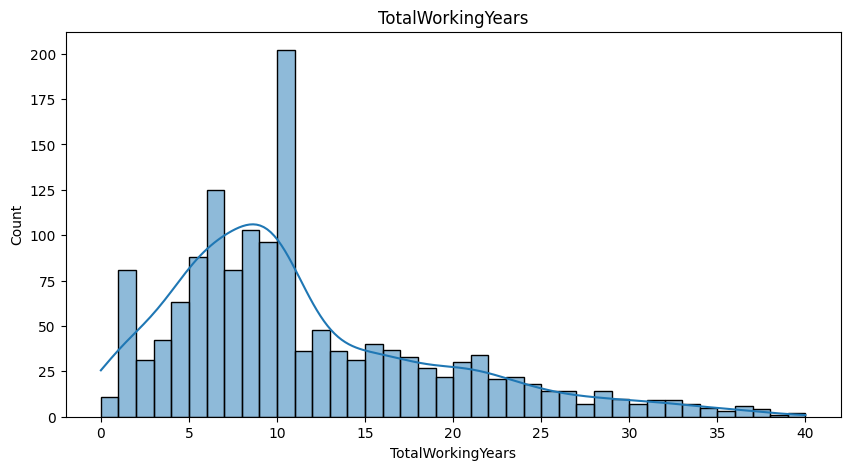

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(df['TotalWorkingYears'], bins=40, kde=True)

plt.title("TotalWorkingYears")
plt.show()

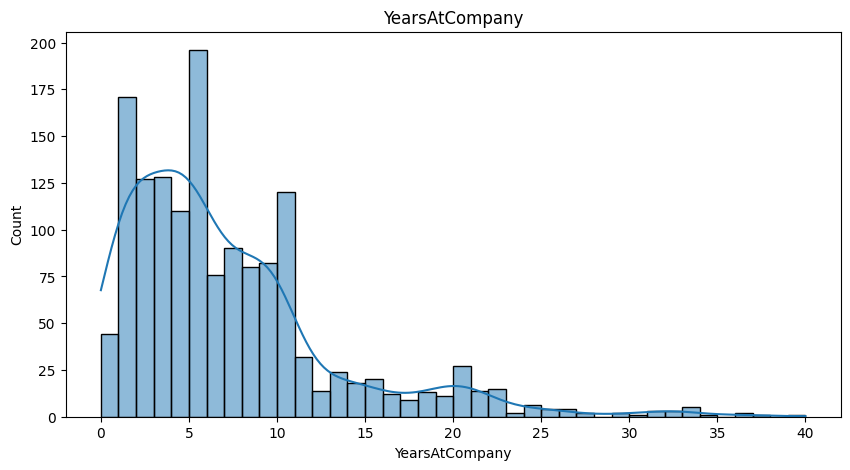

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(df['YearsAtCompany'], bins=40, kde=True)

plt.title("YearsAtCompany")
plt.show()

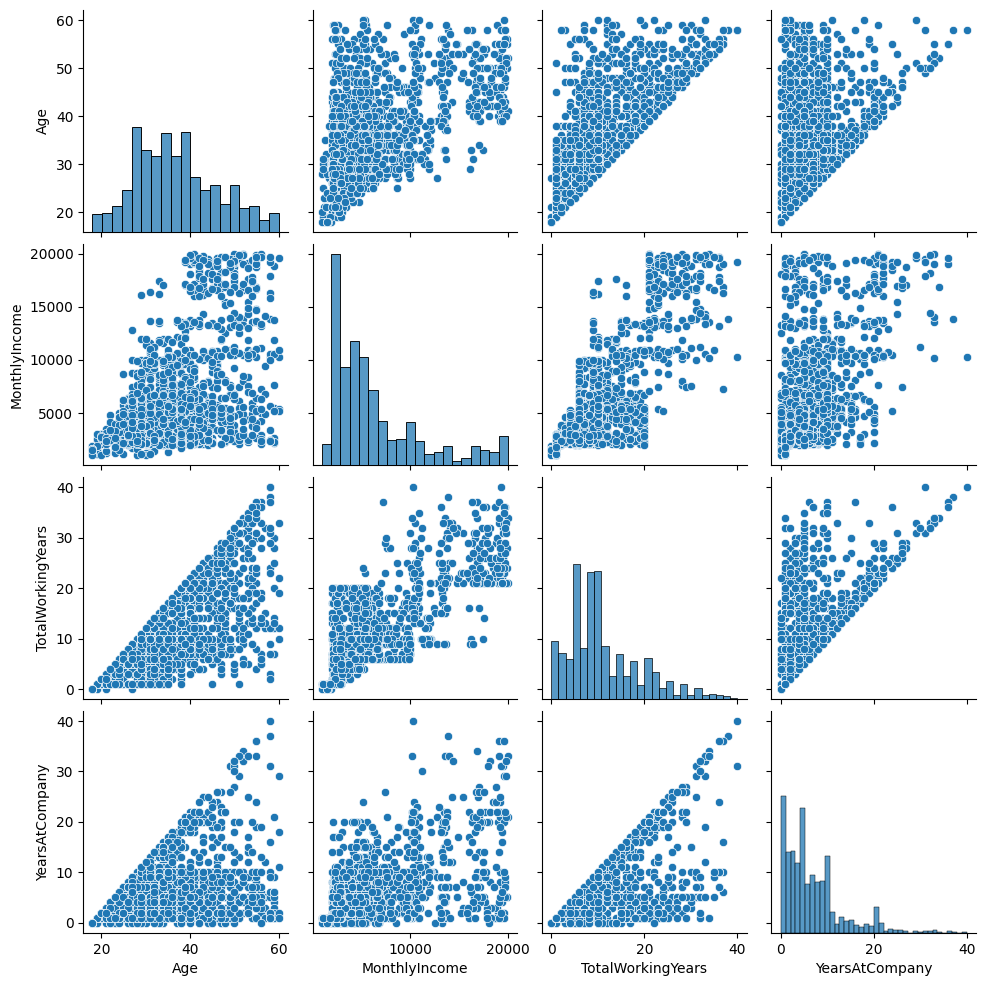

In [10]:
pair_features = [
    "Age",
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsAtCompany"
]
sns.pairplot(df[pair_features])
plt.show()

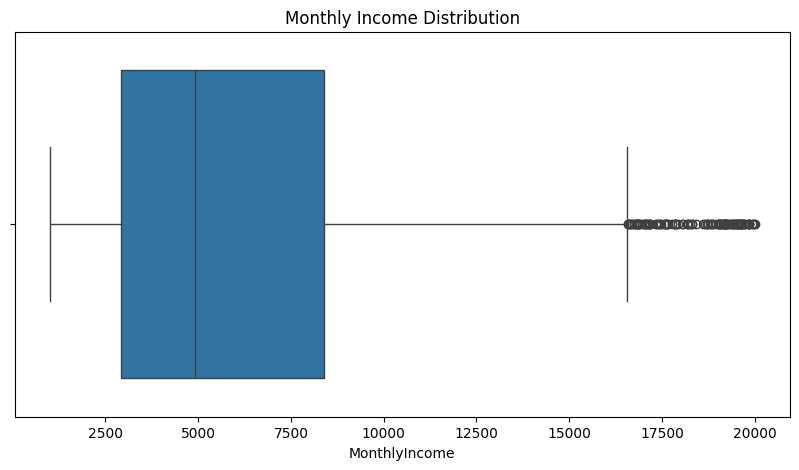

In [11]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df["MonthlyIncome"])
plt.title("Monthly Income Distribution")
plt.show()

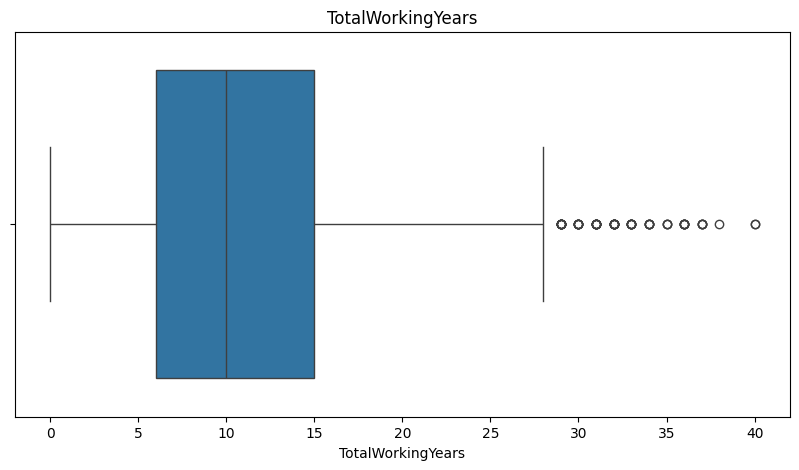

In [12]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df["TotalWorkingYears"])
plt.title("TotalWorkingYears")
plt.show()

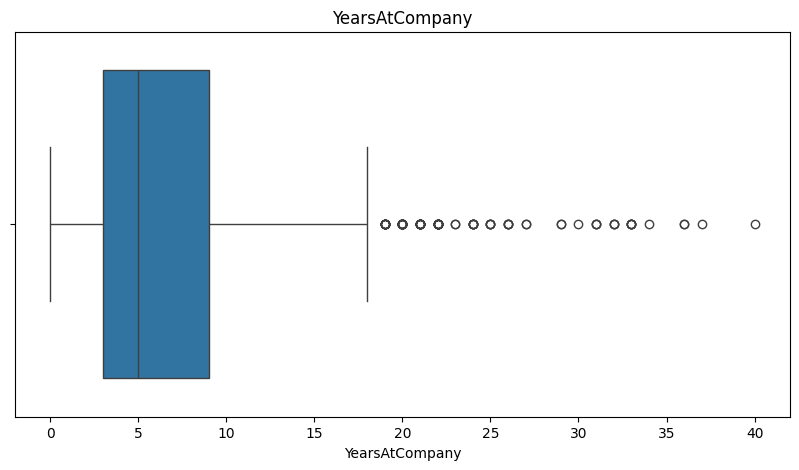

In [13]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df["YearsAtCompany"])
plt.title("YearsAtCompany")
plt.show()

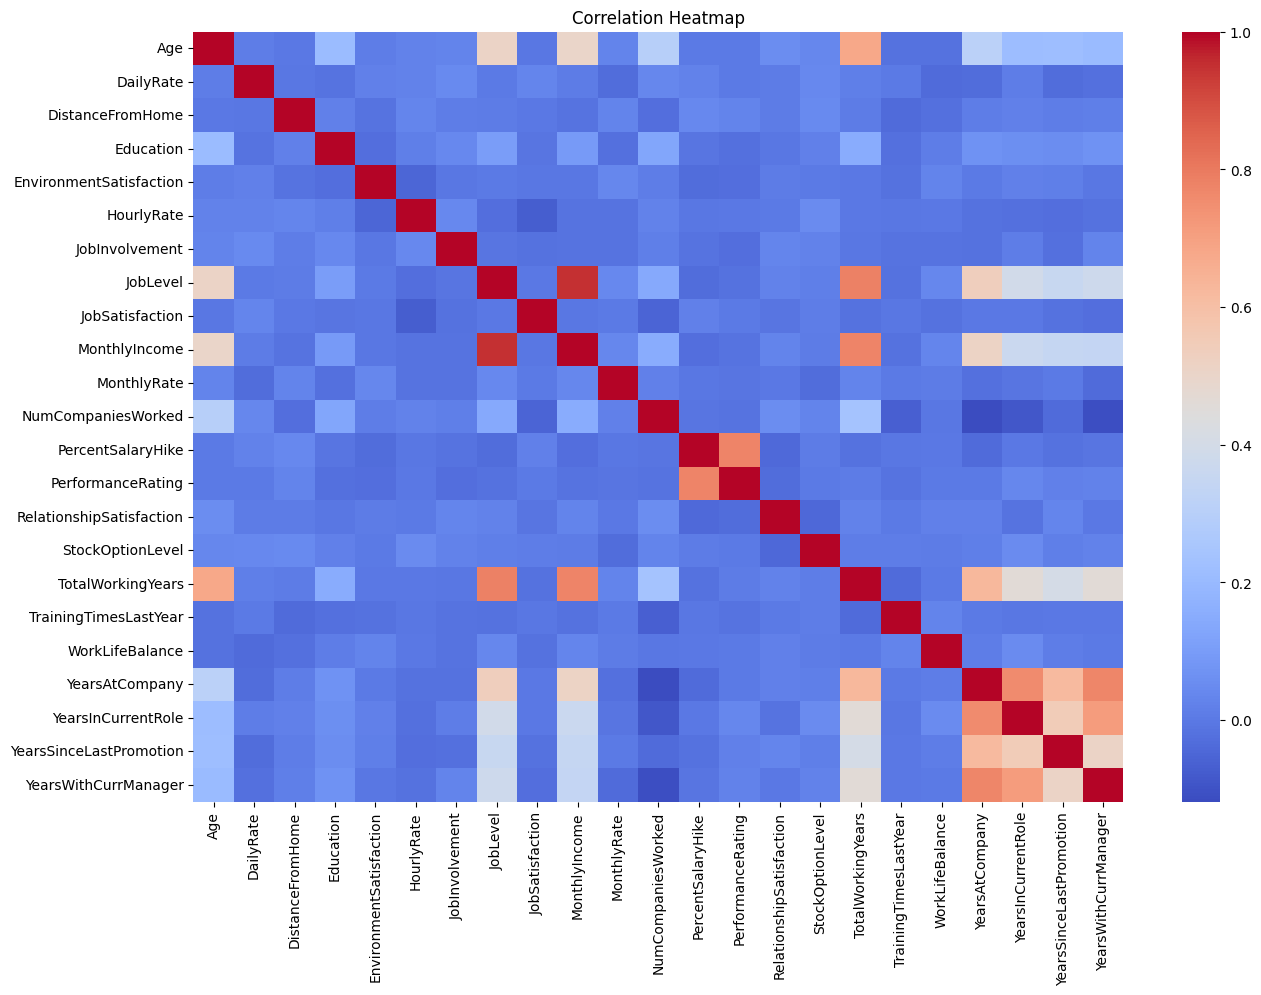

In [14]:
plt.figure(figsize=(15,10))

correlation = df.corr(numeric_only=True)

sns.heatmap(correlation, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

# # Observation
1.The MonthlyIncome distribution contains several high-income outliers. The median monthly income is around ₹5,000–₹6,000, while most employees fall within a moderate income range.

2.Most employees have between 5 and 15 years of total work experience. The distribution shows multiple outliers beyond 28 years, representing a small number of highly experienced employees.

3.Most employees have stayed with the company for fewer than 10 years, with a median tenure of approximately 5 years. Several outliers with tenure greater than 18 years indicate the presence of long-serving employees.

In [15]:
x = df.drop(
    columns=[
        'OverTime',
        'Gender',
        'Education',
        'EducationField'


    ]
)

print(x)

      Age     BusinessTravel  DailyRate              Department  \
0      41      Travel_Rarely       1102                   Sales   
1      49  Travel_Frequently        279  Research & Development   
2      37      Travel_Rarely       1373  Research & Development   
3      33  Travel_Frequently       1392  Research & Development   
4      27      Travel_Rarely        591  Research & Development   
...   ...                ...        ...                     ...   
1465   36  Travel_Frequently        884  Research & Development   
1466   39      Travel_Rarely        613  Research & Development   
1467   27      Travel_Rarely        155  Research & Development   
1468   49  Travel_Frequently       1023                   Sales   
1469   34      Travel_Rarely        628  Research & Development   

      DistanceFromHome  EnvironmentSatisfaction  HourlyRate  JobInvolvement  \
0                    1                        2          94               3   
1                    8               

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
multi_col = ['BusinessTravel', 'Department',
    'JobRole',
    'MaritalStatus']
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), multi_col)], remainder='passthrough')
x = ct.fit_transform(x)
print(x)

[[0. 0. 1. ... 4. 0. 5.]
 [0. 1. 0. ... 7. 1. 7.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 1. ... 2. 0. 3.]
 [0. 1. 0. ... 6. 0. 8.]
 [0. 0. 1. ... 3. 1. 2.]]


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

# # K-Means

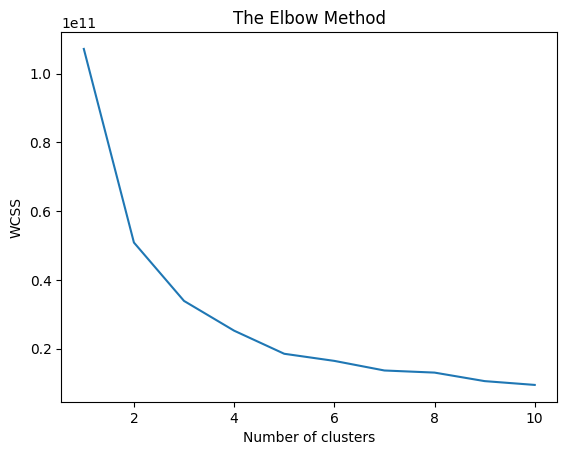

In [18]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++')
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

NOTE: this shows we can select 4 or 5 clusters, we will do both and then compare

# -> clusters = 4

In [19]:
kmeans = KMeans(n_clusters = 4, init = 'k-means++')
y_kmeans = kmeans.fit_predict(x)

In [20]:
df["Cluster"] = y_kmeans

In [21]:
df["Cluster"].value_counts()

,count
Cluster,
1,447
0,441
3,398
2,184


In [22]:
from sklearn.metrics import silhouette_score

score = silhouette_score(x, y_kmeans)

print("Silhouette Score:", score)

Silhouette Score: 0.4168206657398995


In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(x)

In [24]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1","PC2"]
)

pca_df["Cluster"] = y_kmeans

**-> plot with 4 clusters**

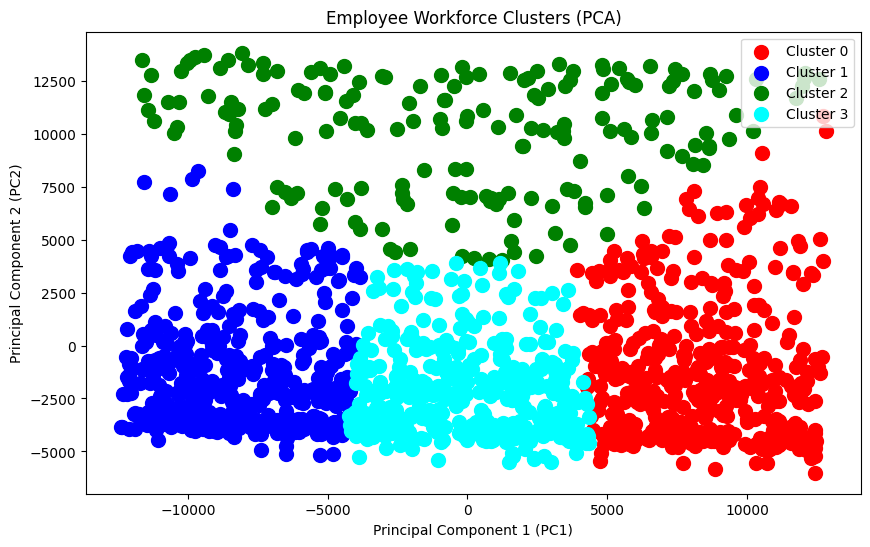

In [25]:
plt.figure(figsize=(10,6))

plt.scatter(X_pca[y_kmeans == 0, 0], X_pca[y_kmeans == 0, 1],
            s=100, c='red', label='Cluster 0')

plt.scatter(X_pca[y_kmeans == 1, 0], X_pca[y_kmeans == 1, 1],
            s=100, c='blue', label='Cluster 1')

plt.scatter(X_pca[y_kmeans == 2, 0], X_pca[y_kmeans == 2, 1],
            s=100, c='green', label='Cluster 2')

plt.scatter(X_pca[y_kmeans == 3, 0], X_pca[y_kmeans == 3, 1],
            s=100, c='cyan', label='Cluster 3')

plt.title('Employee Workforce Clusters (PCA)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend()

plt.show()

**Understanding from plot**

In [26]:
cluster_info = df.groupby("Cluster").mean(numeric_only=True)

print(cluster_info)

               Age   DailyRate  DistanceFromHome  Education  \
Cluster                                                       
0        36.367347  788.972789          9.560091   2.888889   
1        35.212528  809.402685          9.111857   2.957494   
2        46.472826  812.413043          8.500000   3.000000   
3        35.047739  805.100503          9.195980   2.849246   

         EnvironmentSatisfaction  HourlyRate  JobInvolvement  JobLevel  \
Cluster                                                                  
0                       2.712018   66.204082        2.714286  1.918367   
1                       2.684564   66.176734        2.740492  1.711409   
2                       2.760870   65.798913        2.804348  4.222826   
3                       2.756281   65.266332        2.701005  1.623116   

         JobSatisfaction  MonthlyIncome  ...  PerformanceRating  \
Cluster                                  ...                      
0               2.750567    5736.598639  .

# -> clusters = 5

In [27]:
kmeans = KMeans(n_clusters = 5, init = 'k-means++')
y_kmeans = kmeans.fit_predict(x)

In [28]:
df["Cluster"] = y_kmeans

In [29]:
df["Cluster"].value_counts()

,count
Cluster,
0,394
3,393
4,390
1,148
2,145


In [30]:
from sklearn.metrics import silhouette_score

score = silhouette_score(x, y_kmeans)

print("Silhouette Score:", score)

Silhouette Score: 0.4348889851046963


**-> plot for 5 clusters**

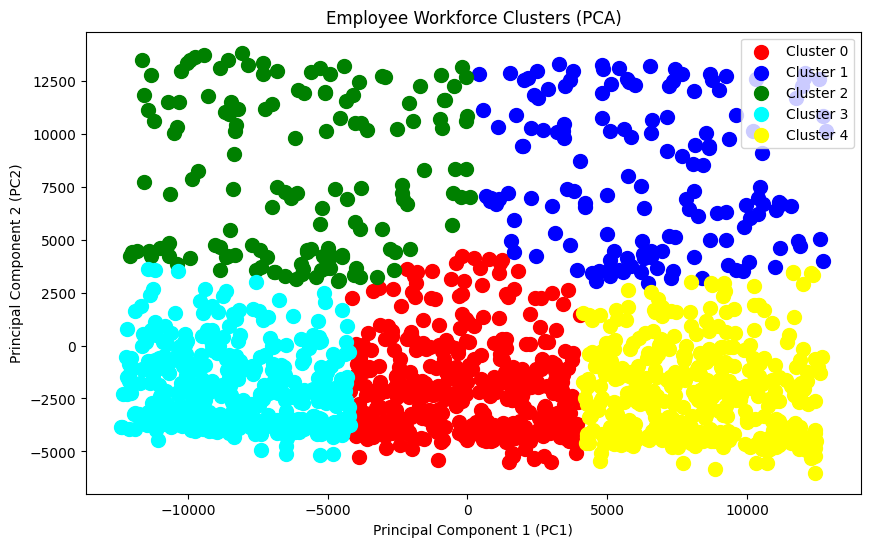

In [31]:
plt.figure(figsize=(10,6))

plt.scatter(X_pca[y_kmeans == 0, 0], X_pca[y_kmeans == 0, 1],
            s=100, c='red', label='Cluster 0')

plt.scatter(X_pca[y_kmeans == 1, 0], X_pca[y_kmeans == 1, 1],
            s=100, c='blue', label='Cluster 1')

plt.scatter(X_pca[y_kmeans == 2, 0], X_pca[y_kmeans == 2, 1],
            s=100, c='green', label='Cluster 2')

plt.scatter(X_pca[y_kmeans == 3, 0], X_pca[y_kmeans == 3, 1],
            s=100, c='cyan', label='Cluster 3')

plt.scatter(X_pca[y_kmeans == 4, 0], X_pca[y_kmeans == 4, 1],
            s=100, c='yellow', label='Cluster 4')

plt.title('Employee Workforce Clusters (PCA)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend()

plt.show()

**understanding from plot**

In [32]:
cluster_info = df.groupby("Cluster").mean(numeric_only=True)

print(cluster_info)

               Age   DailyRate  DistanceFromHome  Education  \
Cluster                                                       
0        35.131980  805.362944          9.144670   2.850254   
1        45.648649  768.020270          8.567568   3.074324   
2        44.000000  827.586207          9.275862   2.993103   
3        34.554707  811.027990          8.997455   2.941476   
4        35.179487  794.717949          9.643590   2.856410   

         EnvironmentSatisfaction  HourlyRate  JobInvolvement  JobLevel  \
Cluster                                                                  
0                       2.738579   65.192893        2.703046  1.649746   
1                       2.729730   64.736486        2.689189  3.851351   
2                       2.655172   65.296552        2.682759  3.758621   
3                       2.697201   66.613232        2.773537  1.541985   
4                       2.751282   66.528205        2.746154  1.700000   

         JobSatisfaction  MonthlyIncome

**-> we would choose clusters = 5 as the plot is more clear and silhouette is also increased little bit**

# # Insights

-> Cluster 0:
Early-to-mid career employees with moderate experience, lower job levels, and below-average income.

-> Cluster 1:
Highly experienced senior employees with the highest income and advanced job positions.

-> Cluster 2:
Experienced professionals with high income and long tenure, slightly below Cluster 1 in seniority.

-> Cluster 3:
Young-to-mid career employees with lower income, lower job levels, and relatively shorter organizational tenure.

-> Cluster 4:
Developing employees with moderate experience, improving career growth, and stable income levels.

# # Hierarchical Clustering

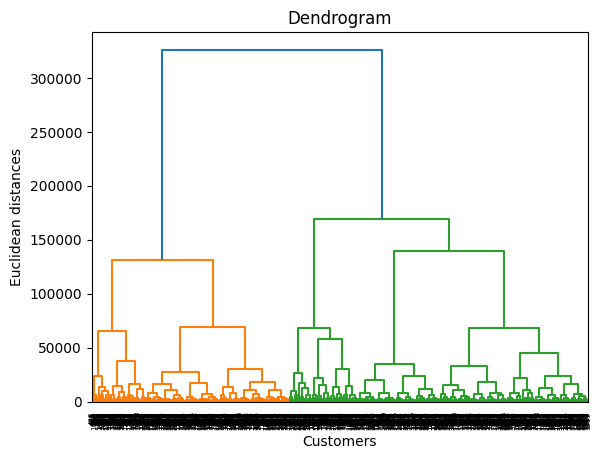

In [33]:
from scipy.cluster import hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(x, method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

**NOTE: DENDROGRAM** was generated using Ward linkage to determine the appropriate number of clusters. The largest vertical distances in the dendrogram suggest multiple possible cluster cuts. While a cut near the top would produce 2 broad clusters, it would result in overly generalized employee groups. Therefore,**5 clusters** were selected to maintain consistency with the K-Means analysis and to obtain more meaningful workforce segments.

In [34]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters = 5, linkage = 'ward')
y_hc = hc.fit_predict(x)

In [35]:
df["Cluster"] = y_hc

In [36]:
df["Cluster"].value_counts()

,count
Cluster,
1,440
0,430
3,243
2,201
4,156


In [37]:
from sklearn.metrics import silhouette_score

score = silhouette_score(x, y_hc)

print("Silhouette Score:", score)

Silhouette Score: 0.37283315351105806


In [38]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(x)

In [39]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1","PC2"]
)

pca_df["Cluster"] = y_hc

**-> Plot**

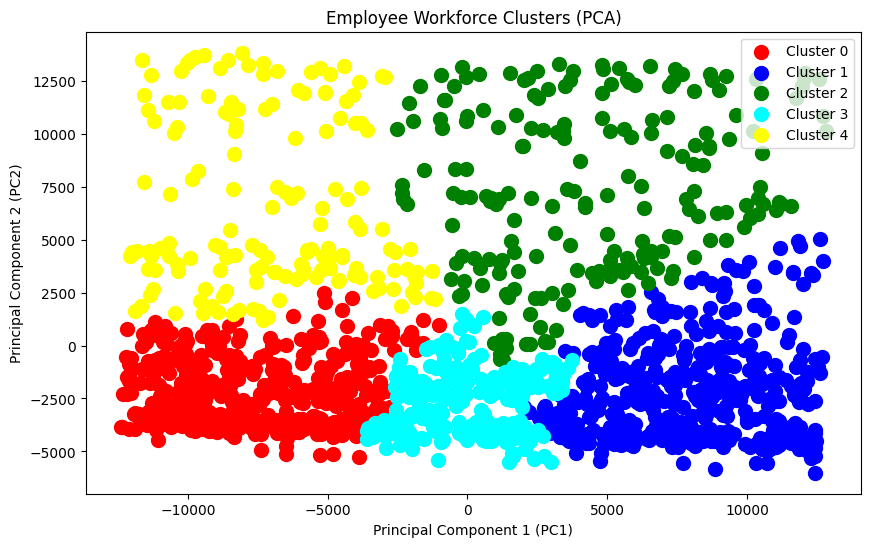

In [40]:
plt.figure(figsize=(10,6))

plt.scatter(X_pca[y_hc == 0, 0], X_pca[y_hc == 0, 1],
            s=100, c='red', label='Cluster 0')

plt.scatter(X_pca[y_hc == 1, 0], X_pca[y_hc == 1, 1],
            s=100, c='blue', label='Cluster 1')

plt.scatter(X_pca[y_hc == 2, 0], X_pca[y_hc == 2, 1],
            s=100, c='green', label='Cluster 2')

plt.scatter(X_pca[y_hc == 3, 0], X_pca[y_hc == 3, 1],
            s=100, c='cyan', label='Cluster 3')

plt.scatter(X_pca[y_hc == 4, 0], X_pca[y_hc == 4, 1],
            s=100, c='yellow', label='Cluster 4')

plt.title('Employee Workforce Clusters (PCA)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend()

plt.show()

**understanding the plot using heirarchical clustering**

In [41]:
cluster_info = df.groupby("Cluster").mean(numeric_only=True)

print(cluster_info)

               Age   DailyRate  DistanceFromHome  Education  \
Cluster                                                       
0        34.469767  801.739535          8.962791   2.934884   
1        34.822727  788.809091          9.468182   2.847727   
2        44.865672  793.696517          8.761194   3.059701   
3        35.045267  811.024691          9.094650   2.823045   
4        42.307692  841.141026          9.756410   2.987179   

         EnvironmentSatisfaction  HourlyRate  JobInvolvement  JobLevel  \
Cluster                                                                  
0                       2.655814   66.423256        2.760465  1.506977   
1                       2.718182   66.559091        2.738636  1.684091   
2                       2.761194   63.935323        2.711443  3.691542   
3                       2.823045   65.893004        2.716049  1.506173   
4                       2.705128   65.057692        2.666667  3.442308   

         JobSatisfaction  MonthlyIncome

# CONCLUSION

K-Means Clustering ->

- Employee workforce segmentation was performed using K-Means Clustering.
- The Elbow Method suggested that 4–5 clusters were appropriate for the dataset.
- After experimentation, 5 clusters were selected.
- The model achieved a Silhouette Score of 0.43, indicating reasonably well-separated employee groups.
- PCA was used to reduce the feature space to two dimensions for visualization, and the resulting clusters showed clear separation.

Hierarchical Clustering ->

- Agglomerative Hierarchical Clustering was also applied using the same preprocessed dataset.
- The dendrogram provided insight into the hierarchical relationships among employees.
- Using 5 clusters, the model achieved a Silhouette Score of 0.37.
- The cluster separation was weaker compared to K-Means.

**K-Means outperformed Hierarchical Clustering on this dataset.K-Means was selected as the preferred clustering technique for employee workforce segmentation.**